# Tutorial 0: Intro material for LAT Workshop

In this introductory tutorial, we will give a basic overview of a few Python topics that are essential to understanding and using codes developed within the LISA Analysis Tools environment. You will also get an initial understanding how the tutorials are structured. ,

This module is meant to be completed before the workshop. It will also ensure installation is successful.

* Tasks: throughout the tutorials, you will be given "tasks." These will direct the tutorial approach and separate the tutorials into natural sections. 
* Questions: additional questions are given within larger tasks. These will sometimes involve coding, sometimes not. A lot of them are meant to be discussion questions for yourself or small groups.
* Structure: Depending on the task at hand, we will provide a specific intruction, small amounts of code, and documentation that is helpful to complete the task. The user must do most or all of the actual coding in order to make these notebooks run successfully. **Note**: in many cases, tutorials within the specific code bases are also available that can you close to the right answer. Most instances, the user will have to navigate these tutorials to find helpful answers. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
from lisatools.utils.constants import *

## Task 1: build and initialize a class object. 

Classes are essential objects in the construction of LISA Analysis Tools and its associated codes. Understanding and using classes will maximize your understanding and capabilities with LISA Analysis Tools. 


Build a class object that has two methods: `__init__` and `get_wave`. 

In `__init__`, store a frequency, amplitude, and initial phase.

In `get_wave`, enter a time array as an argument. Then use the frequency, amplitude, and initial phase stored in `self` and the time array to return a sinusoidal function result to the user.

Helpful documentation:
* [Python class objects](https://docs.python.org/3/tutorial/classes.html#class-objects)

In [2]:
import numpy as np

class WaveGenerator:
    def __init__(self, frequency, amplitude, initial_phase):
        # 这里是“出厂设置”，把参数存进 self 
        self.f = frequency
        self.A = amplitude
        self.phi = initial_phase

    def get_wave(self, t):
        # 这里是“功能按键”，根据存好的参数和传入的时间 t 计算波形
        return self.A * np.cos(2 * np.pi * self.f * t + self.phi)


Now, instantiate the class by providing the necessary arguments. Build a numpy array for the time array and test your class output .

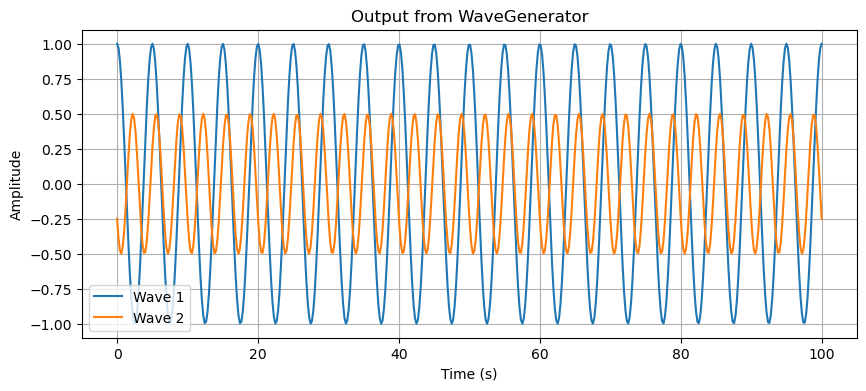

In [10]:
# 给参数赋值：频率 f=0.2, 振幅 A=1.0, 初始相位 phi=0
# my_generator = WaveGenerator(frequency=0.2, amplitude=1.0, initial_phase=0.0)
my_generator1 = WaveGenerator(0.2,1.0,0.0)# 有相同的效果
my_generator2= WaveGenerator(0.3,0.5,2/3*np.pi)
# 2. 构建 numpy 时间数组 (Build time array)
# 使用 np.linspace 创建一个从 0 到 10 秒的数组，包含 500 个点
t=np.linspace(0, 100, 500)
# 调用你写的 get_wave 方法
wave_data1= my_generator1.get_wave(t)
wave_data2=my_generator2.get_wave(t)
plt.figure(figsize=(10, 4))
plt.plot(t, wave_data1,label='Wave 1')
plt.plot(t,wave_data2,label='Wave 2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Output from WaveGenerator')
plt.grid(True)
plt.legend()
plt.show()


## Task 2: `*args` and `**kwargs`

Another topic that is essential to using `lisatools`, is the usage of `*args` and `**kwargs`. These are ways to have flexible passage of Arguments (`*args`) and Keyword Arguments (`**kwargs`). Here, we will experiment with a few ways this works.

Useful documentation:
* [examples](https://www.geeksforgeeks.org/args-kwargs-python/)

试验，上面的结果表现为：真正起作用的是\*,而不是后面的名字，名字用`*args`是约定速成的东西。

\*是代表无关键字的不特定数量的输入 

\*\*是有关键字的不特定数量的输入

In Python, *args and **kwargs are used to allow functions to accept an arbitrary number of arguments. These features provide great flexibility when designing functions that need to handle a varying number of inputs.

*args如何将多个位置参数收集到元组中，以及**kwargs如何将关键字参数收集到字典中。

`args`:Non-keyword (positional) arguments(参数)

`kwargs`:Keyword arguments

当我们对函数中应该传递的参数数量有疑问时，我们使用“`wildcard`”或“\*”表示法——*args或**kwargs——作为函数的参数。

In [16]:
def myFun(*args):
    for arg in args:
        print(arg)

myFun('Hello', 'Welcome', 'to', 'GeeksforGeeks')


def myFun1(*argv):  # 把名字换成 argv
    for arg in argv:
        print(arg)

myFun1('Hello', 'Welcome') # 运行完全正常

Hello
Welcome
to
GeeksforGeeks
Hello
Welcome


In [18]:
def fun(**kwargs):
    for k, val in kwargs.items():
        print(k, "=", val)

fun(s1='Python', s2='is', s3='Awesome')

s1 = Python
s2 = is
s3 = Awesome


In [19]:
def student_info(*args, **kwargs):
    print("Subjects:", args)        # Positional arguments
    print("Details:", kwargs)       # Keyword arguments

# Passing subjects as *args and details as **kwargs
student_info("Math", "Science", "English", Name="Alice", Age=20, City="New York")

Subjects: ('Math', 'Science', 'English')
Details: {'Name': 'Alice', 'Age': 20, 'City': 'New York'}


We are effectively going to copy those examples. Start by designing a function that takes a flexible number of arguments and prints them out. The function signature will be `func(*args)`. In this case, args will be an iterable, so you can iterate through the arguments with a for loop. 

In [23]:
def func(*As):
    for i in As:
        print(i)
func("A","B","C")


def func(*args):
    for arg in args:
        print(arg)
func("A","B","C")

A
B
C
A
B
C


Add a few arguments into the function signature before `*args` and observe how that changes.

In [30]:
def func(first,second,*As):
    for i in As:
        print(i)
    print(second)
    print(first)
func("A","B","C","1","231321")

C
1
231321
B
A


如果在`*args`前面，输入其他函数参数，则在之前输入的参数，就会被拦截，而不是进入`args`。

Now do the same things for `func(**kwargs)`. This will produce a dictionary, so print that in a for loop. 

In [35]:
def func(**kwargs):
    for keyword,val in kwargs.items():
        print(keyword+':'+val)

func(Name="Tim",Age="21",weight="60kg")


Name:Tim
Age:21
weight:60kg


如果要取`**kwargs`中的key和value，需要在kwargs后面加上`.items()`

`**kwargs` can be very useful when making functions flexible because you can have it field the specific `kwargs` needed and store any others in the `**kwargs` dictionary. Add keyword arguments into the function signature and see how it changes the printing results. 

In [45]:
# 这里的 Name 和 Age 就是我们从 **kwargs 中“提取”出来的特定参数
def func(Name, Age, **kwargs):
    print(f"姓名: {Name}")
    print(f"年龄: {Age}")
    for key, val in kwargs.items():
        print(f"{key}: {val}")

# 调用时，传进去一堆参数
func(Name="Tim", Age="21", Weight="60kg", Major="Physics", Mission="LISA")

姓名: Tim
年龄: 21
Weight: 60kg
Major: Physics
Mission: LISA


需要注意的是，这里的`func()`中定义的Key，比如和下面的`func(Name,Age)`相同否则，会报错。

You can also perform effectively the inverted operations. You can enter an iterable into a function call with `*args` and it will spread out your iterable to the args in the function signature. Make a function call with 2 arguments only. Then, create a list that has 2 entries. Enter it into the function call with `*list` and print the output in the function.

In [49]:
# 1. 创建一个只有 2 个参数的函数
def physics_params(freq, amp):
    print(f"频率 (Frequency): {freq}")
    print(f"振幅 (Amplitude): {amp}")

# 2. 创建一个只有 2 个条目的列表
my_list = [0.2, "1e-21"]
# my_list = [0.2, "1e-21",0.3] physics_params() takes 2 positional arguments but 3 were given
# 3. 使用 *my_list 进行调用（解包）
physics_params(*my_list)

频率 (Frequency): 0.2
振幅 (Amplitude): 1e-21


Same type of thing works for kwargs with any input dictionary called like `**dict`. Do the same thing as above for `kwargs`.

In [58]:
# 使用 **kwargs 来接收所有打包进来的字典参数
def myfun(**kwargs):
    # 这里的 kwargs 就是一个真正的字典实例
    for key, value in kwargs.items():
        print(f"{key}:{value}")

# 字典的键必须是字符串，对应函数想要的参数名
dict1 = {"y": "1", "x": "c", "z": "q"}

myfun(**dict1)

y:1
x:c
z:q


In [62]:
def func(x=2, y=1, z=3):
    print(x, y, z)

in_dict = {"x": 1.0, "y": 10, "z": " :) "}
func(**in_dict)

in_dict = {"z": 1.0, "y": 10}
func(**in_dict)


# 你的实际科研场景可能是这样的：
def generate_waveform(f=1e-3, A=1e-21, phi=0.0):
    # 计算波形的逻辑...
    pass

# 你可以准备一个基础参数字典
base_config = {"f": 0.2, "A": 1.0} 

# 以后想改参数，只需改字典，不需要改函数调用那一行
generate_waveform(**base_config)

1.0 10  :) 
2 10 1.0


## Task 3: Class inheritance

Class inheritance gets a bit more complex. It is not essential to know this for the workshop specifically, but it can really help you understand LISA Analysis Tools and other abstracted code libraries designed for future development and maintenance. 

Copy your class from above. Add a keyword argument to the `__init__` function that takes a vertical bias from zero for the sinusoidal function (a float value). Store it to `self`. Inside of `get_wave` add this value onto the end of the sinusoidal return value. 

**Note**: make sure any value entered for $A$ is not too many orders of magnitude away from this added bias factor. Otherwise, you may have issues with machine precision.


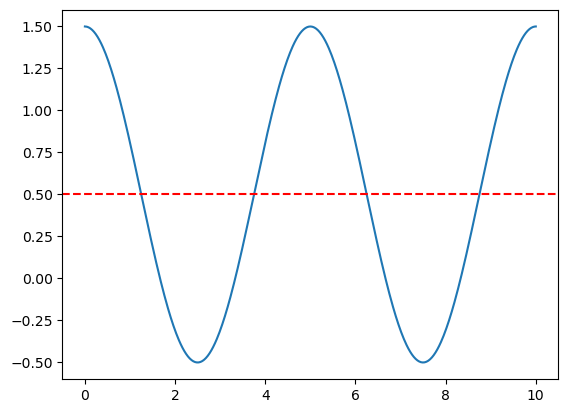

In [63]:
class BiasedWaveGenerator:
    # 1. 在 __init__ 里增加 bias 参数，建议给个默认值 0.0
    def __init__(self, frequency, amplitude, initial_phase, bias=0.0):
        self.f = frequency
        self.A = amplitude
        self.phi = initial_phase
        self.bias = bias # 存储到 self

    def get_wave(self, t):
        # 2. 在公式末尾加上 bias
        wave = self.A * np.cos(2 * np.pi * self.f * t + self.phi)
        return wave + self.bias

# 测试一下（注意精度匹配）
test_gen = BiasedWaveGenerator(0.2, 1.0, 0.0, bias=0.5)
t = np.linspace(0, 10, 500)
plt.plot(t, test_gen.get_wave(t))
plt.axhline(0.5, color='red', linestyle='--') # 画出 bias 的基准线
plt.show()


Now, we will create a class that will inherit our class above and adjust its output on the way through the computation. Add two methods to this class:

In `__init__`, have it take in a single argument representing a multiplicative factor (a float value). Store it in `self`. Then, in the function signature, make sure it is flexible by adding an adjustable number of arguments and keyword arguments. Pass these arguments and keyword arguments to the parent class with this type of line: 
```
super(ChildClass, self).__init__(*args, **kwargs)
```

`__call__` methods on functions allow the user to initialize a class and pass it as a function or `callable`. In other words: `c = Class()` -> `y = c(x)`, rather than having to name a specific method like `get_wave`. 

Useful Documentation:
* [`__call__`](https://www.geeksforgeeks.org/__call__-in-python/) (this is a clickable link)

In `__call__`, take one argument, the time array (numpy array), and put it into the `get_wave` method. Take the output from `get_wave` and multiply by the stored multiplicative factor. Return that to the user. 

学习：The `__call__` method enables Python programmers to write classes where the instances behave like funcation and can be called like a function. 

这是非常形象的：
`c = Class()` -> `y = c(x)`

When this method is defined, calling an object (`obj(arg1, arg2)`) automatically triggers `obj.__call__(arg1, arg2)`. This makes objects behave like functions, enabling more flexible and reusable code.


结构
```
class Example:
    def __init__(self):
        # code

    # Defining __call__ method
    def __call__(self):
        # code
```


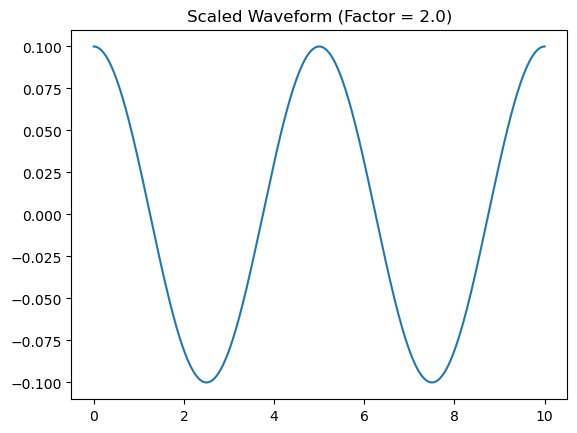

In [65]:
# 假设父类是 WaveGenerator
class ModifiedWaveGenerator(WaveGenerator):
    def __init__(self, factor, *args, **kwargs):
        # 1. 存储自己的倍率因子
        self.factor = float(factor)
        
        # 2. 核心：把剩下的所有参数 (*args, **kwargs) 传给父类
        # 这样你就不用在这里重复写 self.f = f, self.A = A 等等
        super(ModifiedWaveGenerator, self).__init__(*args, **kwargs)

    def __call__(self, t):
        # 3. 这里定义“直接调用对象”时发生的事情
        # 先调用继承来的 get_wave 方法拿到原始波形
        original_wave = self.get_wave(t)
        
        # 4. 乘上倍率因子并返回
        return original_wave * self.factor

# --- 测试一下 ---
# 传入倍率因子 2.0，后面跟着父类需要的参数 (f, A, phi)
my_fancy_gen = ModifiedWaveGenerator(2.0, 0.2, 0.05, 0.0)

t = np.linspace(0, 10, 500)

# 现在可以直接像调用函数一样使用对象了！
wave = my_fancy_gen(t) 

plt.plot(t, wave)
plt.title("Scaled Waveform (Factor = 2.0)")
plt.show()


Now initialize and test your class.

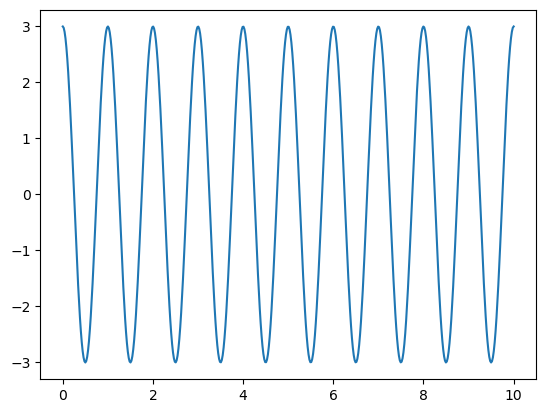

In [88]:
class ModifiedWaveGenerator2(ModifiedWaveGenerator):
    def __init__(self, factor1, *args, **kwargs):
        self.factor1=float(factor1)
        super(ModifiedWaveGenerator2,self).__init__(*args, **kwargs)
    #def __call__(self, t):
        #orignGw=self.get_wave(t)
        #return orignGw*(1/self.factor1)#这直接调用了爷爷辈的数据了，factor就失效了
    def __call__(self, t):
    # 用 super() 调用父类的 __call__
        parent_wave = super(ModifiedWaveGenerator2,self).__call__(t) 
        return parent_wave * (1/self.factor1)

my_fancy_gen1=ModifiedWaveGenerator2(10,3,1,10,0.0)
t = np.linspace(0, 10, 500)
wave = my_fancy_gen1(t) 

plt.plot(t, wave)
#plt.title("Scaled Waveform (Factor = 2.0)")
plt.show()

## A `pdb` manifesto. 

(Michael's opinion)

The python debugger ([pdb](https://docs.python.org/3/library/pdb.html)) is an unbelievably helpful tool. For me, it is up there with `Numpy` and `Matplotlib` in terms of how useful it has been for me. It has shaved so much time from the development process, it is honestly incalculable. `pdb` allows you to use most one-line `ipython` commands stopped anywhere in your code. In other words, you can stop your Python code and run functions, print any stored variables, store new variables, plot things, etc.

I notice that a lot of people do not know about this intrinsic python library or do not use it. 


The start of my development code file is usually:
```
import numpy as np


if __name__ == "__main__":

    # debugger at the end to catch and analyze any output. 
    breakpoint()  
```

I often do, what I am now calling as of writting this, "proactive debugging." Proactive debugging means that the code is run until it reaches a point where I am about to develop. I will then develop line by line in the debugger, testing each line as I go. Once it works, it gets pasted in the code. This is a little tedious to get used to and does not work sometimes (only sometimes), but I highly recommend trying it. It is a very efficient way to develop code in my opinion.  

We are not going to practice it here because it really does not work as well in a notebook. It is more useful in the terminal. In the terminal, it is an almost ipython-like experience stopping anywhere in the code you place a `breakpoint`. You can use it to stop inside functions you design, or inside python codes of others. In other words, you can open a python code that is in your `$PATH` and place a breakpoint inside of it. You can then run your code that calls this package. It will stop at your breakpoint. You can step through and print anything you need. This has really helped me in the past to learn better coding techniques and to understanding complex codes others have designed. 

Here is the documentation:
* [pdb](https://docs.python.org/3/library/pdb.html)

学习：在`ipynb`中无需使用breakpoint()，即可在一个地方断开。

但是在`.py`程序无法实现这样的操作。


探索阶段 (`.ipynb`)：在 Notebook 里胡乱尝试，调调参数，画画图，看看波形长什么样。

整理阶段 (`.py`)：把试出来的核心算法逻辑提取出来，写成整洁的 .py 函数库。

生产阶段 (`.py`)：写一个主程序脚本调用这些函数库，丢到服务器上进行大规模并行计算。

而是开始写真正的 .py 脚本时，如果程序报错让你摸不着头脑，记得在报错的那一行前面加上：
```
breakpoint()
```
运行代码后，程序会停在那，你可以直接在控制台输入变量名看看发生了什么。这就够了。